<a href="https://colab.research.google.com/github/RamonEppens/Analisis_Predictivo_Co2/blob/main/notebooks/Examen1-An%C3%A1lisisPredictivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Predictivo — Examen 1
## Predicción de emisiones de CO₂ per cápita por país
**Dataset:** Our World in Data — CO2 and Greenhouse Gas Emissions  
**Fuente:** github.com/owid/co2-data  
**Grupo:** Ramón Eppens · Moira Patricia Clacin · María Belen Piuma Justo

**ITBA — 2026**

In [2]:
# === LIBRERÍAS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# --- Configuración visual global: Tufte + ColorBrewer ---
# Solo parámetros que matplotlib acepta en todas las versiones
plt.rcParams.update({
    'figure.facecolor':   'white',
    'axes.facecolor':     'white',
    'savefig.facecolor':  'white',
    'axes.grid':          False,       # lo manejamos manualmente por gráfico
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'font.family':        'sans-serif',
    'axes.titlesize':     12,
    'axes.titleweight':   'normal',
    'axes.titlepad':      10,
    'axes.labelsize':     10,
    'axes.labelcolor':    '#333333',
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
    'xtick.color':        '#555555',
    'ytick.color':        '#555555',
    'legend.fontsize':    9,
    'legend.frameon':     False,
    'figure.titlesize':   13,
    'xtick.direction':    'out',
    'ytick.direction':    'out',
    'xtick.major.size':   3,
    'ytick.major.size':   3,
})

# Función helper — aplicar estilo Tufte a cualquier eje
def tufte_style(ax, grid_axis='y'):
    """
    Aplica estilo minimalista Tufte:
    - Spines solo izquierdo y bottom, en gris claro
    - Grilla solo en un eje, sutil
    - Sin tick marks en el eje de las categorías
    """
    # Spines
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color('#cccccc')
        ax.spines[spine].set_linewidth(0.8)

    # Grilla
    if grid_axis == 'y':
        ax.yaxis.grid(True,  color='#e0e0e0', linewidth=0.5, zorder=0)
        ax.xaxis.grid(False)
        ax.yaxis.set_tick_params(length=0)
    else:
        ax.xaxis.grid(True,  color='#e0e0e0', linewidth=0.5, zorder=0)
        ax.yaxis.grid(False)
        ax.xaxis.set_tick_params(length=0)

    ax.set_axisbelow(True)  # grilla detrás de las barras

# --- Paleta ColorBrewer ---
C_BLUE   = '#2166ac'   # secuencial — barras e histogramas principales
C_RED    = '#d73027'   # alerta — outliers, skewness alto
C_GREEN  = '#1a9850'   # positivo / referencia
C_ORANGE = '#f46d43'   # highlight — medianas, anotaciones
C_GRAY   = '#737373'   # elementos secundarios

print("Librerías y configuración visual cargadas ✓")

Librerías y configuración visual cargadas ✓


In [3]:
# === CARGA DEL DATASET ===
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df  = pd.read_csv(url)

print(f"Dataset cargado ✓")
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado ✓
Dimensiones: 50,411 filas × 79 columnas


In [4]:
# === PRIMER VISTAZO ===
df.head(10)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Afghanistan,1755,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Afghanistan,1756,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Afghanistan,1757,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Afghanistan,1758,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Afghanistan,1759,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Tipos de datos por columna
df.dtypes.value_counts()

,count
float64,76
object,2
int64,1


In [6]:
# Lista de columnas
for i, col in enumerate(df.columns):
    print(f"{i+1:>3}. {col}")

  1. country
  2. year
  3. iso_code
  4. population
  5. gdp
  6. cement_co2
  7. cement_co2_per_capita
  8. co2
  9. co2_growth_abs
 10. co2_growth_prct
 11. co2_including_luc
 12. co2_including_luc_growth_abs
 13. co2_including_luc_growth_prct
 14. co2_including_luc_per_capita
 15. co2_including_luc_per_gdp
 16. co2_including_luc_per_unit_energy
 17. co2_per_capita
 18. co2_per_gdp
 19. co2_per_unit_energy
 20. coal_co2
 21. coal_co2_per_capita
 22. consumption_co2
 23. consumption_co2_per_capita
 24. consumption_co2_per_gdp
 25. cumulative_cement_co2
 26. cumulative_co2
 27. cumulative_co2_including_luc
 28. cumulative_coal_co2
 29. cumulative_flaring_co2
 30. cumulative_gas_co2
 31. cumulative_luc_co2
 32. cumulative_oil_co2
 33. cumulative_other_co2
 34. energy_per_capita
 35. energy_per_gdp
 36. flaring_co2
 37. flaring_co2_per_capita
 38. gas_co2
 39. gas_co2_per_capita
 40. ghg_excluding_lucf_per_capita
 41. ghg_per_capita
 42. land_use_change_co2
 43. land_use_change_co2_per_

## 1. Descripción general del dataset

In [7]:
# === DIMENSIONES Y TIPOS DE DATOS ===
print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"\nTipos de datos:")
print(df.dtypes.value_counts())

Filas:    50,411
Columnas: 79

Tipos de datos:
float64    76
object      2
int64       1
Name: count, dtype: int64


In [8]:
# === INFO GENERAL ===
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

### 1.1 Estadísticas descriptivas

In [9]:
# === ESTADÍSTICAS DESCRIPTIVAS ===
# Solo columnas numéricas, redondeado a 2 decimales
df.describe().round(2)

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50411.00,4.116700e+04,1.525100e+04,29173.00,25648.00,29384.00,27216.00,26239.00,23796.00,23496.00,...,2170.00,41238.00,38280.00,41238.00,41238.00,38280.00,38150.00,37813.00,4712.00,4712.00
mean,1920.35,6.017453e+07,3.300495e+11,7.89,0.06,420.23,6.27,42.60,544.14,7.48,...,7.19,2.27,0.00,0.01,0.01,0.00,490.80,310.52,-6.99,21.47
std,65.86,3.308433e+08,3.086383e+12,62.99,0.12,1972.09,62.20,1721.91,2273.28,99.51,...,17.45,9.28,0.02,0.05,0.06,0.00,2414.08,1812.36,259.02,62.64
min,1750.00,2.150000e+02,4.998000e+07,0.00,0.00,0.00,-1928.34,-100.00,-84.56,-2298.98,...,0.00,-0.82,-0.00,0.00,-0.00,0.00,-19.73,0.00,-2177.81,-98.28
25%,1875.00,3.272140e+05,7.874038e+09,0.00,0.00,0.38,-0.00,-1.07,6.67,-0.73,...,0.14,0.00,0.00,0.00,0.00,0.00,1.50,0.22,-2.26,-6.83
50%,1925.00,2.291594e+06,2.743861e+10,0.00,0.00,5.08,0.04,3.81,28.12,0.11,...,0.59,0.08,0.00,0.00,0.00,0.00,14.61,2.22,1.64,8.38
75%,1975.00,9.986553e+06,1.212627e+11,0.52,0.08,53.66,1.02,10.88,124.30,2.77,...,2.42,0.37,0.00,0.00,0.00,0.00,76.51,27.86,11.43,32.78
max,2024.00,8.161973e+09,1.301126e+14,1666.88,2.48,38598.58,1804.66,180870.00,43184.09,2614.87,...,100.00,100.00,0.38,1.22,1.68,0.08,54433.40,43714.78,1768.85,1023.04


### 1.2 Valores faltantes

Columnas con valores faltantes: 77 de 79
Columnas sin ningún nulo:       2



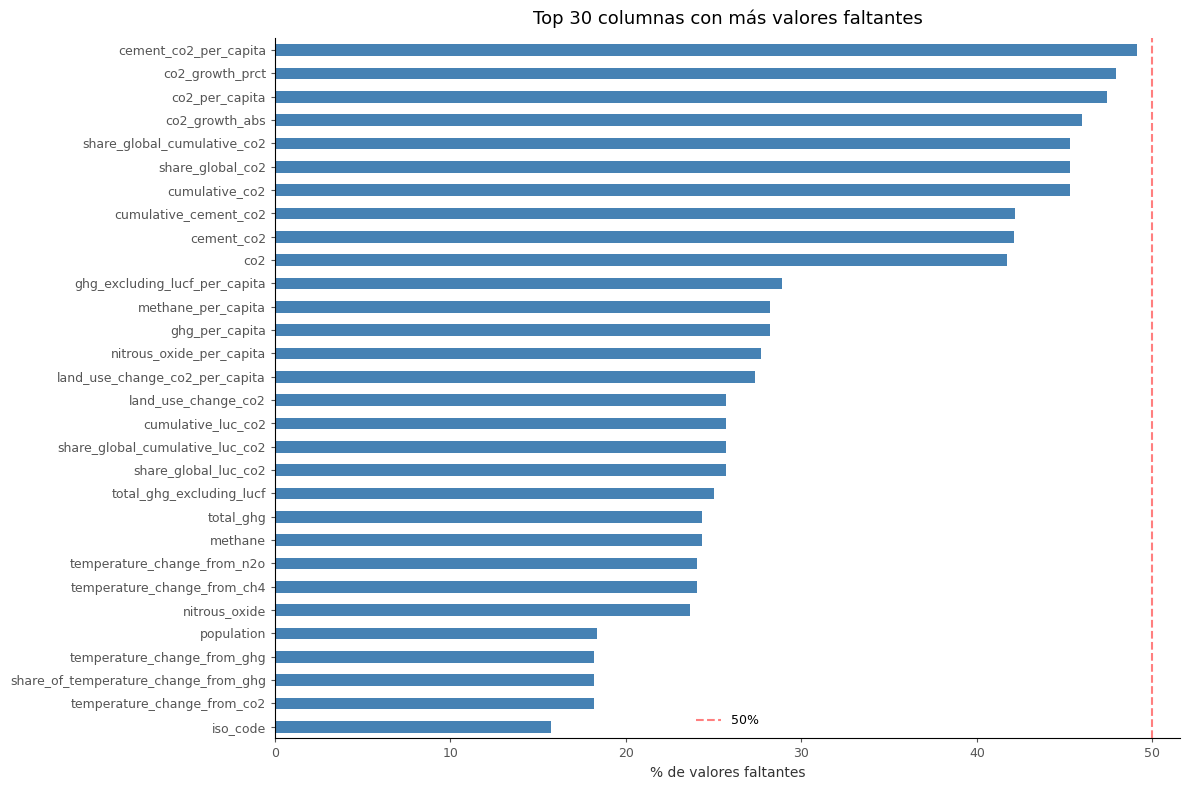

In [10]:
# === VALORES FALTANTES ===
# Calcular % de nulos por columna
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]  # Solo columnas con al menos un nulo

print(f"Columnas con valores faltantes: {len(missing)} de {df.shape[1]}")
print(f"Columnas sin ningún nulo:       {df.shape[1] - len(missing)}\n")

# Graficar las 30 columnas con más nulos
fig, ax = plt.subplots(figsize=(12, 8))
missing.sort_values(ascending=True).head(30).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Top 30 columnas con más valores faltantes', fontsize=13)
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50%')
ax.legend()
plt.tight_layout()
plt.show()

### 1.3 Cobertura temporal y geográfica

Rango de años: 1750 — 2024
Países/regiones únicos: 254


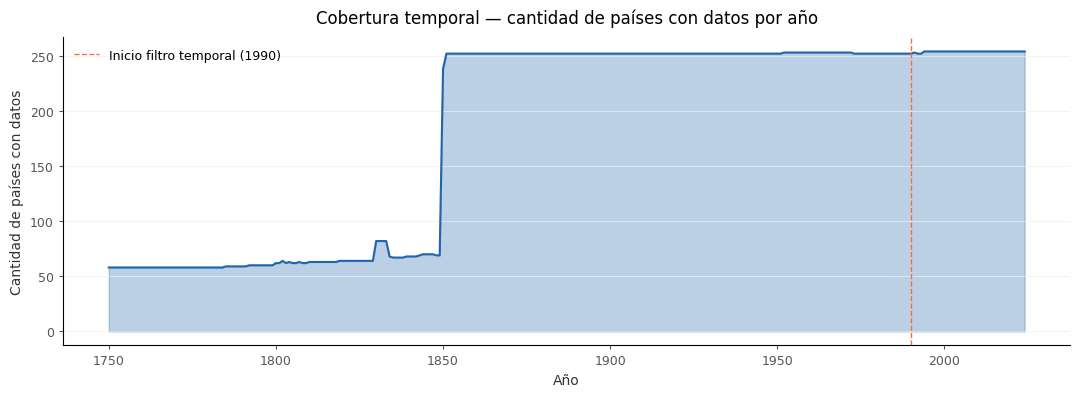

In [11]:
# === COBERTURA TEMPORAL ===
print(f"Rango de años: {df['year'].min()} — {df['year'].max()}")
print(f"Países/regiones únicos: {df['country'].nunique()}")

cobertura = df.groupby('year')['country'].count()

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(cobertura.index, cobertura.values,
                color=C_BLUE, alpha=0.3)
ax.plot(cobertura.index, cobertura.values,
        color=C_BLUE, linewidth=1.5)

ax.axvline(1990, color=C_ORANGE, linewidth=1, linestyle='--',
           label='Inicio filtro temporal (1990)')
ax.set_xlabel('Año')
ax.set_ylabel('Cantidad de países con datos')
ax.set_title('Cobertura temporal — cantidad de países con datos por año')
ax.grid(axis='x', visible=False)
ax.grid(axis='y', color='#eeeeee', linewidth=0.5)
ax.legend()
plt.show()

In [12]:
# === AGREGADOS REGIONALES ===
aggregates = df[df['iso_code'].isna()]['country'].unique()
print(f"Agregados regionales encontrados ({len(aggregates)}):")
for a in sorted(aggregates):
    print(f"  - {a}")

Agregados regionales encontrados (36):
  - Africa
  - Africa (GCP)
  - Asia
  - Asia (GCP)
  - Asia (excl. China and India)
  - Central America (GCP)
  - Europe
  - Europe (GCP)
  - Europe (excl. EU-27)
  - Europe (excl. EU-28)
  - European Union (27)
  - European Union (28)
  - High-income countries
  - International aviation
  - International shipping
  - Kosovo
  - Kuwaiti Oil Fires
  - Kuwaiti Oil Fires (GCP)
  - Least developed countries (Jones et al.)
  - Low-income countries
  - Lower-middle-income countries
  - Middle East (GCP)
  - Non-OECD (GCP)
  - North America
  - North America (GCP)
  - North America (excl. USA)
  - OECD (GCP)
  - OECD (Jones et al.)
  - Oceania
  - Oceania (GCP)
  - Ryukyu Islands
  - Ryukyu Islands (GCP)
  - South America
  - South America (GCP)
  - Upper-middle-income countries
  - World


## 2. Filtros y limpieza

### 2.1 Eliminar agregados regionales

In [13]:
# === ELIMINAR AGREGADOS REGIONALES ===
df_countries = df[df['iso_code'].notna()].copy()

print(f"Dataset original:  {df.shape[0]:,} filas · {df['country'].nunique()} entidades")
print(f"Solo países:       {df_countries.shape[0]:,} filas · {df_countries['country'].nunique()} países")
print(f"Filas eliminadas:  {df.shape[0] - df_countries.shape[0]:,}")

Dataset original:  50,411 filas · 254 entidades
Solo países:       42,480 filas · 218 países
Filas eliminadas:  7,931


### 2.2 Filtro temporal: 1990–2022

In [14]:
# === FILTRO TEMPORAL ===
df_clean = df_countries[
    (df_countries['year'] >= 1990) &
    (df_countries['year'] <= 2022)
].copy()

print(f"Con filtro temporal: {df_clean.shape[0]:,} filas")
print(f"Años cubiertos:      {df_clean['year'].min()} — {df_clean['year'].max()}")
print(f"Países:              {df_clean['country'].nunique()}")

Con filtro temporal: 7,194 filas
Años cubiertos:      1990 — 2022
Países:              218


### 2.3 Selección de columnas para el EDA

No filtramos columnas pensando en el modelo (eso es tarea del TP3), sino que eliminamos únicamente:
- Columnas con **más del 70% de valores nulos** → insuficientes datos para analizar
- Columnas **duplicadas o casi idénticas** → misma información expresada de forma redundante

In [15]:
# === ELIMINAR COLUMNAS CON MÁS DEL 50% DE NULOS ===
thresh = 0.50
nulos_pct = df_clean.isnull().mean()
cols_muchos_nulos = nulos_pct[nulos_pct > thresh].index.tolist()

print(f"Columnas eliminadas por más del 50% de nulos ({len(cols_muchos_nulos)}):")
for col in cols_muchos_nulos:
    print(f"  {col:<45} {nulos_pct[col]*100:.1f}%")

df_clean = df_clean.drop(columns=cols_muchos_nulos)
print(f"\nColumnas restantes: {df_clean.shape[1]}")

Columnas eliminadas por más del 50% de nulos (5):
  cumulative_other_co2                          78.9%
  other_co2_per_capita                          78.9%
  other_industry_co2                            78.9%
  share_global_cumulative_other_co2             78.9%
  share_global_other_co2                        78.9%

Columnas restantes: 74


In [16]:
# === ELIMINAR COLUMNAS REDUNDANTES ===
cols_redundantes = [
    # Share global — ya tenemos los valores absolutos
    'share_global_cement_co2',
    'share_global_co2',
    'share_global_coal_co2',
    'share_global_flaring_co2',
    'share_global_oil_co2',
    'share_global_cumulative_cement_co2',
    'share_global_cumulative_co2_including_luc',
    'share_global_cumulative_coal_co2',
    'share_global_cumulative_flaring_co2',
    'share_global_cumulative_luc_co2',
    'share_global_cumulative_oil_co2',
    'share_global_cumulative_gas_co2',
    'share_global_gas_co2',
    'share_global_co2_including_luc',
    'share_global_luc_co2',
    'share_global_cumulative_co2',
    # Acumulados — conservamos solo cumulative_co2
    'cumulative_cement_co2',
    'cumulative_co2_including_luc',
    'cumulative_coal_co2',
    'cumulative_flaring_co2',
    'cumulative_luc_co2',
    'cumulative_oil_co2',
    'cumulative_gas_co2',
    # Versiones including_luc — redundantes con versiones base
    'co2_including_luc',
    'co2_including_luc_growth_abs',
    'co2_including_luc_growth_prct',
    'co2_including_luc_per_capita',
    'co2_including_luc_per_gdp',
    'co2_including_luc_per_unit_energy',
    # Temperature change — conservamos solo temperature_change_from_co2
    'temperature_change_from_ch4',
    'temperature_change_from_n2o',
    'temperature_change_from_ghg',
    'share_of_temperature_change_from_ghg',
    # GHG — conservamos ghg_per_capita
    'total_ghg',
    'total_ghg_excluding_lucf',
    'ghg_excluding_lucf_per_capita',
    # Otras redundantes
    'trade_co2_share',
    'trade_co2',
    'consumption_co2_per_gdp',
]

cols_redundantes = [c for c in cols_redundantes if c in df_clean.columns]
df_clean = df_clean.drop(columns=cols_redundantes)

print(f"Columnas eliminadas: {len(cols_redundantes)}")
print(f"Columnas finales:    {df_clean.shape[1]}")
print(f"\n{df_clean.columns.tolist()}")

Columnas eliminadas: 39
Columnas finales:    35

['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'cumulative_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 'methane_per_capita', 'nitrous_oxide', 'nitrous_oxide_per_capita', 'oil_co2', 'oil_co2_per_capita', 'primary_energy_consumption', 'temperature_change_from_co2']


In [17]:
# === ELIMINAR VARIABLES CON DATA LEAKAGE ===
# Estas variables son componentes o derivados matemáticos de co2_per_capita.
# Incluirlas como features en el modelo causaría data leakage directo.

cols_leakage = [
    # Componentes directos de co2_per_capita
    'coal_co2',
    'coal_co2_per_capita',
    'oil_co2',
    'oil_co2_per_capita',
    'gas_co2',
    'gas_co2_per_capita',
    'cement_co2',
    'cement_co2_per_capita',
    'flaring_co2',
    'flaring_co2_per_capita',
    'land_use_change_co2',
    'land_use_change_co2_per_capita',
    # co2 total — es co2_per_capita × population
    'co2',
    # Ratios derivados de co2_per_capita
    'co2_per_gdp',
    'co2_per_unit_energy',
    'co2_growth_abs',
    'co2_growth_prct',
    # Versiones alternativas de co2
    'consumption_co2',
    'consumption_co2_per_capita',
    # GHG incluye co2_per_capita dentro
    'ghg_per_capita',
]

cols_leakage = [c for c in cols_leakage if c in df_clean.columns]
df_clean = df_clean.drop(columns=cols_leakage)

print(f"Variables de leakage eliminadas: {len(cols_leakage)}")
print(f"Columnas restantes:              {df_clean.shape[1]}")

Variables de leakage eliminadas: 20
Columnas restantes:              15


In [18]:
# === ELIMINAR VARIABLES NO LEAKAGE PERO PRESCINDIBLES ===
# Estas variables no causan leakage pero son redundantes o
# no estarían fácilmente disponibles al momento de predecir.

cols_prescindibles = [
    'cumulative_co2',             # acumulado histórico muy correlacionado con target
    'temperature_change_from_co2',# derivado de emisiones históricas
    'methane',                    # redundante con methane_per_capita
    'nitrous_oxide',              # redundante con nitrous_oxide_per_capita
    'primary_energy_consumption', # redundante con energy_per_capita
]

cols_prescindibles = [c for c in cols_prescindibles if c in df_clean.columns]
df_clean = df_clean.drop(columns=cols_prescindibles)

print(f"Variables prescindibles eliminadas: {len(cols_prescindibles)}")
print(f"Columnas restantes:                 {df_clean.shape[1]}")
print(f"\nFeatures válidos para el modelo:")
features = [c for c in df_clean.columns
            if c not in ['country', 'iso_code', 'year', 'co2_per_capita']]
for i, f in enumerate(features):
    print(f"  {i+1:>2}. {f}")

Variables prescindibles eliminadas: 5
Columnas restantes:                 10

Features válidos para el modelo:
   1. population
   2. gdp
   3. energy_per_capita
   4. energy_per_gdp
   5. methane_per_capita
   6. nitrous_oxide_per_capita


### 2.4 Resumen del dataset limpio


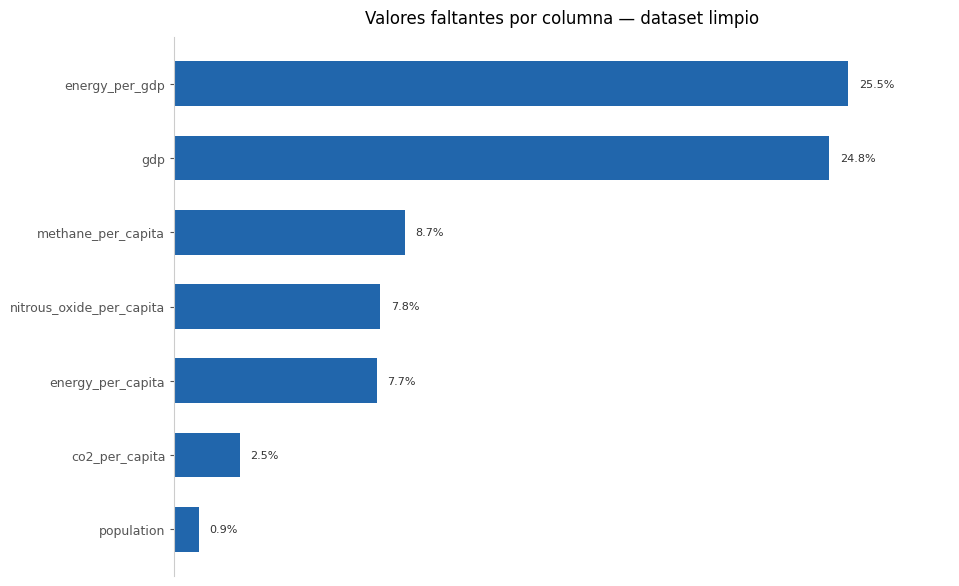

In [19]:
# === VALORES FALTANTES — DATASET LIMPIO ===
missing_clean = df_clean.isnull().mean() * 100
missing_clean = missing_clean[missing_clean > 0].sort_values()

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(missing_clean.index, missing_clean.values,
               color=C_BLUE, height=0.6, edgecolor='none')

for bar, val in zip(bars, missing_clean.values):
    ax.text(val + 0.4, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=8, color='#333333')

ax.set_title('Valores faltantes por columna — dataset limpio')
ax.set_xlim(0, missing_clean.max() * 1.15)
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)
tufte_style(ax, grid_axis='x')
plt.show()

In [20]:
# === RESUMEN FINAL ===
print(f"Dimensiones finales: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas")
print(f"Países:              {df_clean['country'].nunique()}")
print(f"Años:                {df_clean['year'].min()} — {df_clean['year'].max()}")

# Observación sobre la variable respuesta
con_target = df_clean['co2_per_capita'].notna().sum()
sin_target  = df_clean['co2_per_capita'].isna().sum()
print(f"\nFilas con co2_per_capita conocido: {con_target:,}  → para entrenar en TP3")
print(f"Filas con co2_per_capita nulo:     {sin_target:,}  → candidatas a predecir en TP3")

Dimensiones finales: 7,194 filas × 10 columnas
Países:              218
Años:                1990 — 2022

Filas con co2_per_capita conocido: 7,016  → para entrenar en TP3
Filas con co2_per_capita nulo:     178  → candidatas a predecir en TP3


### 2.5 Snapshot del dataset limpio

In [21]:
df_clean.head(10)

,country,year,iso_code,population,gdp,co2_per_capita,energy_per_capita,energy_per_gdp,methane_per_capita,nitrous_oxide_per_capita
240,Afghanistan,1990,AFG,12045664.0,1.306598e+10,0.168,2506.867,2.311,0.559,0.222
241,Afghanistan,1991,AFG,12238879.0,1.204736e+10,0.156,1021.075,1.037,0.574,0.225
242,Afghanistan,1992,AFG,13278983.0,1.267754e+10,0.112,618.055,0.647,0.535,0.202
243,Afghanistan,1993,AFG,14943175.0,9.834582e+09,0.100,545.758,0.829,0.482,0.182
244,Afghanistan,1994,AFG,16250800.0,7.919856e+09,0.089,484.346,0.994,0.461,0.158
245,Afghanistan,1995,AFG,17065837.0,1.230753e+10,0.083,386.490,0.536,0.463,0.157
246,Afghanistan,1996,AFG,17763266.0,1.207013e+10,0.077,368.899,0.543,0.496,0.164
247,Afghanistan,1997,AFG,18452100.0,1.185075e+10,0.071,341.218,0.531,0.520,0.173
248,Afghanistan,1998,AFG,19159996.0,1.169217e+10,0.067,321.278,0.526,0.532,0.181
249,Afghanistan,1999,AFG,19887792.0,1.151732e+10,0.055,309.214,0.534,0.556,0.187


## 3. Análisis de la variable respuesta
La variable respuesta es `co2_per_capita`: toneladas de CO₂ per cápita por país y año.

### 3.1 Estadísticas descriptivas

In [22]:
# === ESTADÍSTICAS DESCRIPTIVAS ===
target = df_clean['co2_per_capita'].dropna()

stats = {
    'Media':            target.mean(),
    'Mediana':          target.median(),
    'Desvío estándar':  target.std(),
    'Mínimo':           target.min(),
    'Máximo':           target.max(),
    'Skewness':         target.skew(),
    'Kurtosis':         target.kurt(),
    'Q1 (25%)':         target.quantile(0.25),
    'Q3 (75%)':         target.quantile(0.75),
    'IQR':              target.quantile(0.75) - target.quantile(0.25),
}

for k, v in stats.items():
    print(f"  {k:<22} {v:.3f}")

  Media                  5.047
  Mediana                2.713
  Desvío estándar        7.912
  Mínimo                 0.000
  Máximo                 364.791
  Skewness               15.324
  Kurtosis               616.950
  Q1 (25%)               0.701
  Q3 (75%)               6.925
  IQR                    6.224


### 3.2 Distribución

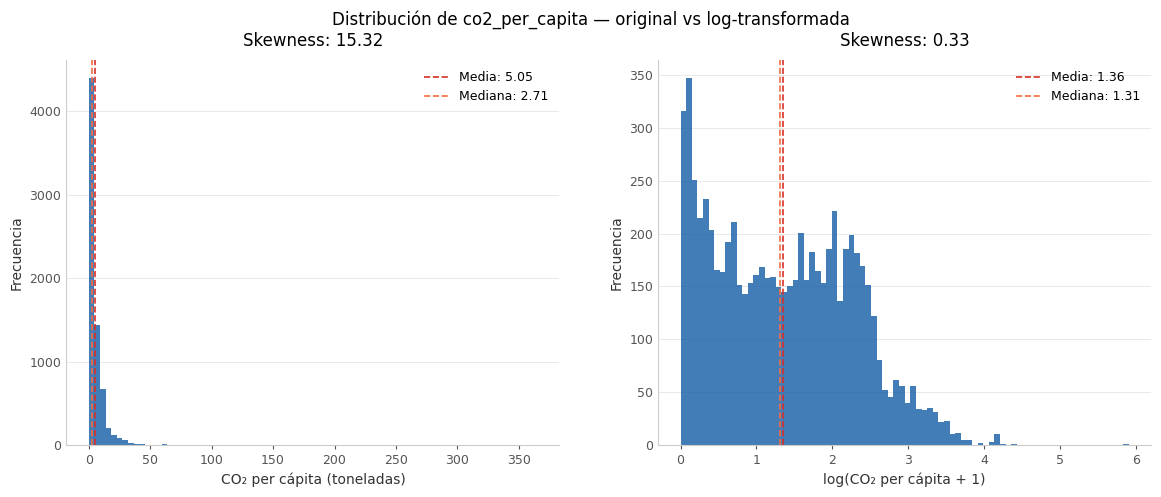

→ La distribución original es fuertemente asimétrica (skewness > 10).
→ La transformación logarítmica la normaliza significativamente.
→ Conclusión: conviene trabajar en escala log para el modelo (TP3).


In [23]:
# === DISTRIBUCIÓN: ORIGINAL VS LOG ===
log_target = np.log1p(target)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, label, note in [
    (axes[0], target,     'CO₂ per cápita (toneladas)',  f'Skewness: {target.skew():.2f}'),
    (axes[1], log_target, 'log(CO₂ per cápita + 1)',     f'Skewness: {log_target.skew():.2f}'),
]:
    ax.hist(data, bins=80, color=C_BLUE, edgecolor='none', alpha=0.85)
    ax.axvline(data.mean(),   color=C_RED,    linewidth=1.2,
               linestyle='--', label=f'Media: {data.mean():.2f}')
    ax.axvline(data.median(), color=C_ORANGE, linewidth=1.2,
               linestyle='--', label=f'Mediana: {data.median():.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'{note}')
    ax.legend()
    tufte_style(ax, grid_axis='y')

fig.suptitle('Distribución de co2_per_capita — original vs log-transformada',
             fontsize=12)
plt.show()

print("→ La distribución original es fuertemente asimétrica (skewness > 10).")
print("→ La transformación logarítmica la normaliza significativamente.")
print("→ Conclusión: conviene trabajar en escala log para el modelo (TP3).")

### 3.3 Boxplot y detección de outliers

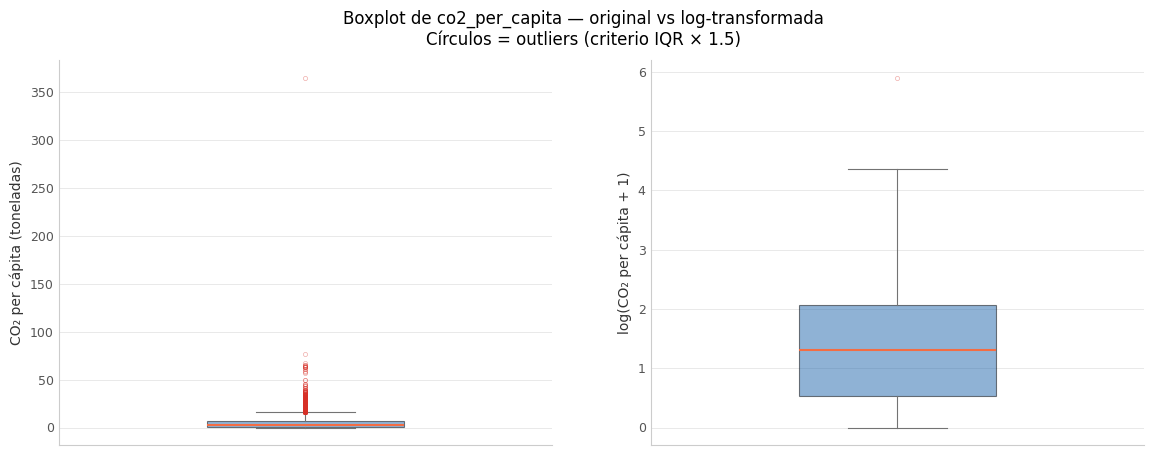

Límite superior IQR: 16.26 toneladas
Outliers detectados: 404 observaciones

Top 15 observaciones más extremas:
country  year  co2_per_capita
 Kuwait  1991         364.791
  Qatar  1997          76.715
  Qatar  2001          67.727
  Qatar  1996          65.162
  Qatar  1994          64.819
  Qatar  1995          64.491
  Qatar  1998          63.665
  Qatar  2002          63.518
  Qatar  1993          63.400
  Qatar  2000          62.646
  Qatar  2003          62.618
  Qatar  2006          61.421
  Qatar  2004          61.344
  Qatar  1999          59.305
  Qatar  2005          57.767


In [24]:
# === BOXPLOT Y OUTLIERS ===
Q1  = target.quantile(0.25)
Q3  = target.quantile(0.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR
lim_inf = Q1 - 1.5 * IQR

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, label in [
    (axes[0], target,     'CO₂ per cápita (toneladas)'),
    (axes[1], log_target, 'log(CO₂ per cápita + 1)'),
]:
    ax.boxplot(data.dropna(), vert=True, patch_artist=True, widths=0.4,
               boxprops=dict(facecolor=C_BLUE, alpha=0.5, linewidth=0.8),
               medianprops=dict(color=C_ORANGE, linewidth=1.5),
               whiskerprops=dict(color=C_GRAY, linewidth=0.8),
               capprops=dict(color=C_GRAY, linewidth=0.8),
               flierprops=dict(marker='o', markersize=3,
                               markerfacecolor='none',
                               markeredgecolor=C_RED,
                               markeredgewidth=0.5,
                               alpha=0.4))
    ax.set_ylabel(label)
    ax.set_xticks([])
    tufte_style(ax, grid_axis='y')

fig.suptitle('Boxplot de co2_per_capita — original vs log-transformada\n'
             'Círculos = outliers (criterio IQR × 1.5)', fontsize=12)
plt.show()

# Identificar outliers
outliers = (df_clean[df_clean['co2_per_capita'] > lim_sup]
            [['country', 'year', 'co2_per_capita']]
            .sort_values('co2_per_capita', ascending=False))

print(f"Límite superior IQR: {lim_sup:.2f} toneladas")
print(f"Outliers detectados: {len(outliers):,} observaciones\n")
print("Top 15 observaciones más extremas:")
print(outliers.head(15).to_string(index=False))

### 3.4 Evolución temporal

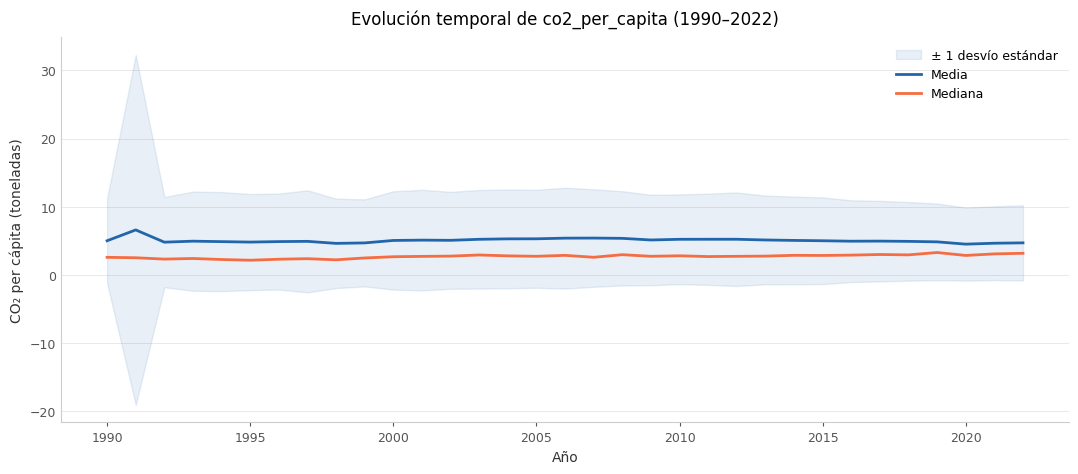

In [25]:
# === EVOLUCIÓN TEMPORAL ===
evolucion = (df_clean.groupby('year')['co2_per_capita']
             .agg(['mean', 'median', 'std'])
             .reset_index())

fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(evolucion['year'],
                evolucion['mean'] - evolucion['std'],
                evolucion['mean'] + evolucion['std'],
                alpha=0.1, color=C_BLUE, label='± 1 desvío estándar')
ax.plot(evolucion['year'], evolucion['mean'],
        color=C_BLUE,   linewidth=2, label='Media')
ax.plot(evolucion['year'], evolucion['median'],
        color=C_ORANGE, linewidth=2, label='Mediana')

ax.set_xlabel('Año')
ax.set_ylabel('CO₂ per cápita (toneladas)')
ax.set_title('Evolución temporal de co2_per_capita (1990–2022)')
ax.legend()
tufte_style(ax, grid_axis='y')
plt.show()

In [26]:
df_clean.groupby('year')['co2_per_capita'].count().head(10)

,co2_per_capita
year,
1990,208
1991,209
1992,211
1993,211
1994,213
1995,213
1996,213
1997,213
1998,213


### 3.5 Países con emisiones más altas y más bajas

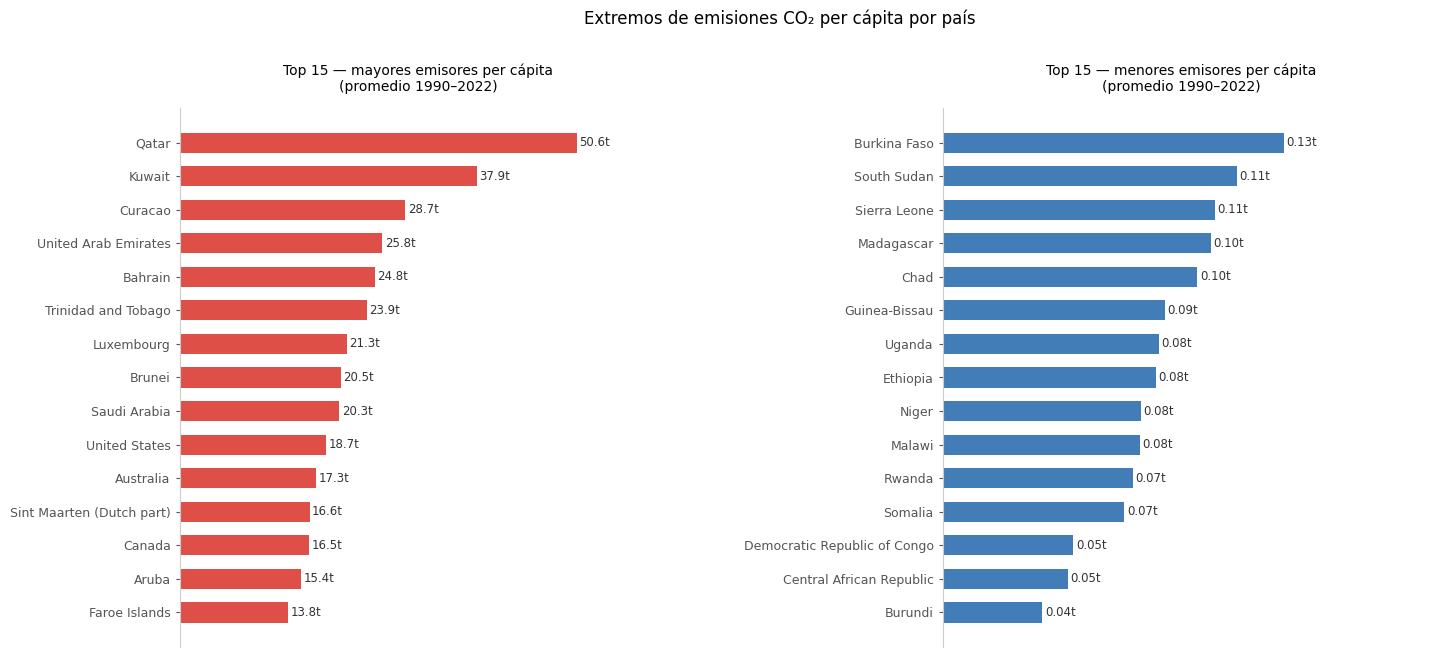


Mayor emisor:  Qatar — 50.6 t/año
Menor emisor:  Burundi — 0.039 t/año


In [27]:
# === TOP Y BOTTOM PAÍSES ===
promedio_pais = (df_clean.groupby('country')['co2_per_capita']
                 .mean().dropna().sort_values(ascending=False))

top15 = promedio_pais.head(15).sort_values(ascending=True)   # descendente visual = ascendente en barh
bot15 = promedio_pais.tail(15).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 15 mayores emisores
axes[0].barh(top15.index, top15.values,
             color=C_RED, height=0.6, edgecolor='none', alpha=0.85)
for i, val in enumerate(top15.values):
    axes[0].text(val + 0.3, i, f'{val:.1f}t',
                 va='center', fontsize=8.5, color='#333333')
axes[0].set_title('Top 15 — mayores emisores per cápita\n(promedio 1990–2022)',
                  fontsize=10, pad=12)
axes[0].set_xlim(0, top15.max() * 1.2)
axes[0].xaxis.set_visible(False)
axes[0].spines['bottom'].set_visible(False)
axes[0].tick_params(axis='y', labelsize=9)
tufte_style(axes[0], grid_axis='x')

# Top 15 menores emisores
axes[1].barh(bot15.index, bot15.values,
             color=C_BLUE, height=0.6, edgecolor='none', alpha=0.85)
for i, val in enumerate(bot15.values):
    axes[1].text(val + 0.001, i, f'{val:.2f}t',
                 va='center', fontsize=8.5, color='#333333')
axes[1].set_title('Top 15 — menores emisores per cápita\n(promedio 1990–2022)',
                  fontsize=10, pad=12)
axes[1].set_xlim(0, bot15.max() * 1.4)
axes[1].xaxis.set_visible(False)
axes[1].spines['bottom'].set_visible(False)
axes[1].tick_params(axis='y', labelsize=9)
tufte_style(axes[1], grid_axis='x')

fig.suptitle('Extremos de emisiones CO₂ per cápita por país',
             fontsize=12, y=1.02)
plt.subplots_adjust(wspace=0.6)
plt.show()

print(f"\nMayor emisor:  {promedio_pais.index[0]} — {promedio_pais.iloc[0]:.1f} t/año")
print(f"Menor emisor:  {promedio_pais.index[-1]} — {promedio_pais.iloc[-1]:.3f} t/año")


## 4. Análisis univariado de features
En esta sección analizamos la distribución individual de cada variable numérica relevante del dataset.

### 4.1 Visión general de todas las variables numéricas

In [28]:
# === ESTADÍSTICAS DESCRIPTIVAS ===
numericas = df_clean.select_dtypes(include='number').drop(columns=['year'])
numericas.describe().round(2)

,population,gdp,co2_per_capita,energy_per_capita,energy_per_gdp,methane_per_capita,nitrous_oxide_per_capita
count,7.128000e+03,5.410000e+03,7016.00,6642.00,5359.00,6567.00,6633.00
mean,3.092390e+07,4.894066e+11,5.05,24315.70,1.54,1.83,0.50
std,1.241387e+08,1.704830e+12,7.91,33930.65,1.47,2.91,0.60
min,5.130000e+02,2.571720e+08,0.00,0.00,0.08,0.04,0.00
25%,6.330200e+05,1.885143e+10,0.70,2674.78,0.74,0.66,0.20
50%,5.455912e+06,6.108450e+10,2.71,11269.23,1.17,1.04,0.32
75%,1.964483e+07,2.913226e+11,6.93,33041.09,1.88,1.71,0.53
max,1.426437e+09,2.696602e+13,364.79,318559.69,23.02,42.77,5.40


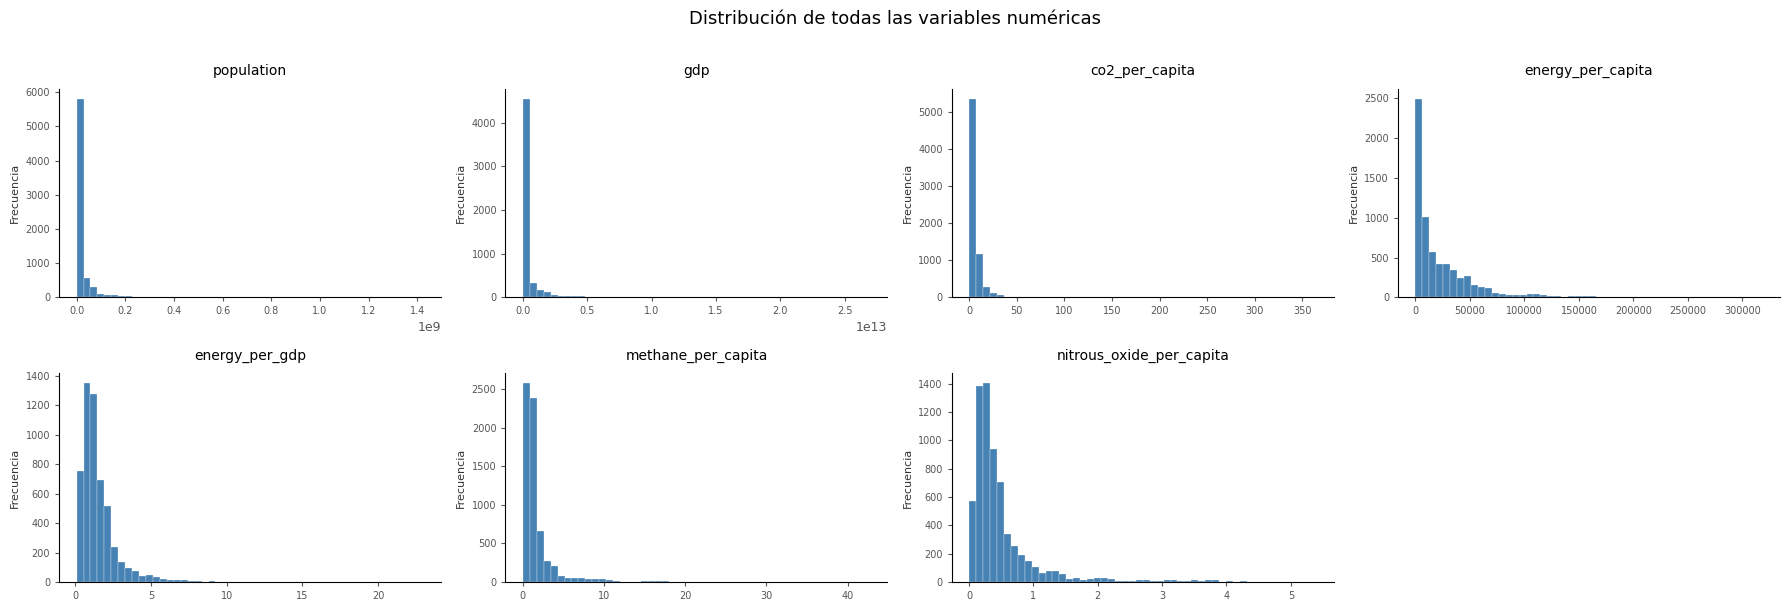

In [29]:
# === DISTRIBUCIÓN DE TODAS LAS VARIABLES NUMÉRICAS ===
# Grid de histogramas para tener una visión rápida de todas las variables
cols_plot = numericas.columns.tolist()
n_cols = 4
n_rows = -(-len(cols_plot) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols_plot):
    data = df_clean[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white', linewidth=0.2)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Frecuencia', fontsize=8)
    axes[i].tick_params(labelsize=7)

# Ocultar ejes vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de todas las variables numéricas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Skewness y necesidad de transformación

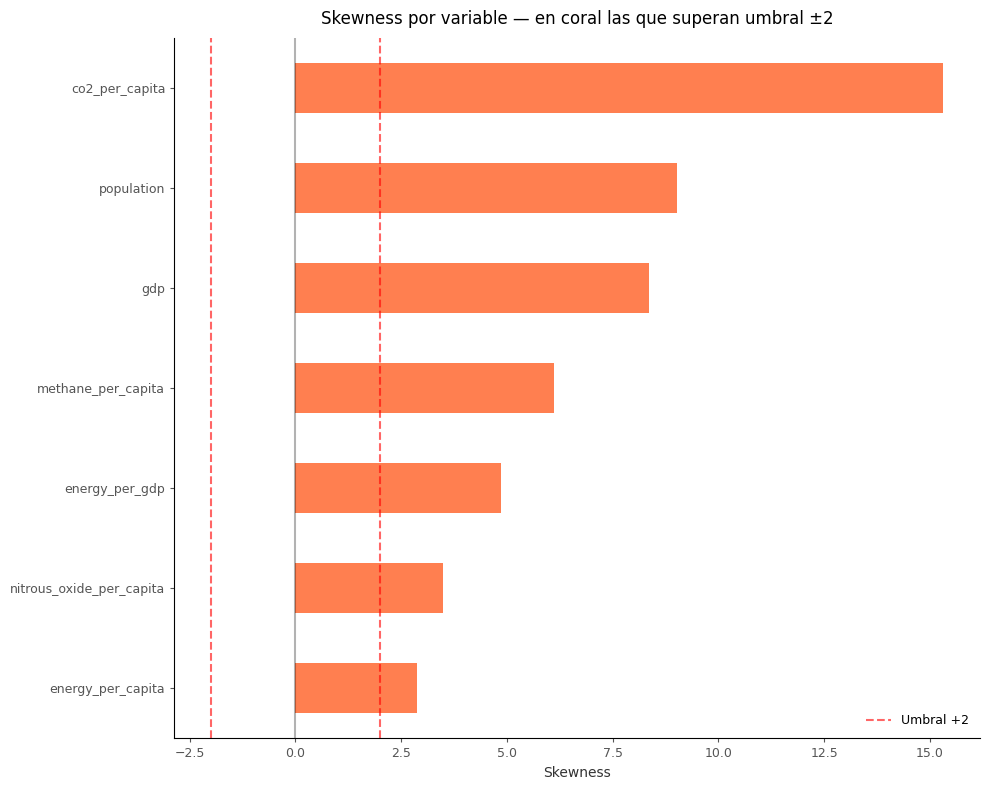

Variables con skewness > 2 (candidatas a transformación logarítmica):
co2_per_capita              15.32
population                   9.03
gdp                          8.36
methane_per_capita           6.11
energy_per_gdp               4.87
nitrous_oxide_per_capita     3.49
energy_per_capita            2.87


In [30]:
# === SKEWNESS DE TODAS LAS VARIABLES ===
skewness = numericas.skew().sort_values(ascending=False).round(2)

fig, ax = plt.subplots(figsize=(10, 8))
colores = ['coral' if abs(s) > 2 else 'steelblue' for s in skewness]
skewness.sort_values().plot(kind='barh', ax=ax, color=colores)
ax.axvline(x=2,  color='red',    linestyle='--', alpha=0.6, label='Umbral +2')
ax.axvline(x=-2, color='red',    linestyle='--', alpha=0.6)
ax.axvline(x=0,  color='black',  linestyle='-',  alpha=0.3)
ax.set_title('Skewness por variable — en coral las que superan umbral ±2', fontsize=12)
ax.set_xlabel('Skewness')
ax.legend()
plt.tight_layout()
plt.show()

print("Variables con skewness > 2 (candidatas a transformación logarítmica):")
print(skewness[abs(skewness) > 2].to_string())

### 4.3 Detección de outliers por IQR

In [31]:
# === DETECCIÓN DE OUTLIERS POR IQR ===
def calcular_outliers(serie):
    Q1  = serie.quantile(0.25)
    Q3  = serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_sup = Q3 + 1.5 * IQR
    lim_inf = Q1 - 1.5 * IQR
    n_outliers = ((serie < lim_inf) | (serie > lim_sup)).sum()
    pct = n_outliers / serie.dropna().shape[0] * 100
    return pd.Series({
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'lim_inf': lim_inf, 'lim_sup': lim_sup,
        'n_outliers': n_outliers, 'pct_outliers': pct
    })

resumen_outliers = numericas.apply(calcular_outliers).T
resumen_outliers = resumen_outliers.sort_values('pct_outliers', ascending=False)
resumen_outliers[['n_outliers', 'pct_outliers', 'lim_inf', 'lim_sup']].round(2)

,n_outliers,pct_outliers,lim_inf,lim_sup
gdp,745.0,13.77,-3.898554e+11,7.000295e+11
population,836.0,11.73,-2.788469e+07,4.816254e+07
methane_per_capita,713.0,10.86,-9.200000e-01,3.290000e+00
nitrous_oxide_per_capita,640.0,9.65,-3.100000e-01,1.040000e+00
energy_per_gdp,342.0,6.38,-9.600000e-01,3.580000e+00
energy_per_capita,408.0,6.14,-4.287469e+04,7.859056e+04
co2_per_capita,404.0,5.76,-8.640000e+00,1.626000e+01


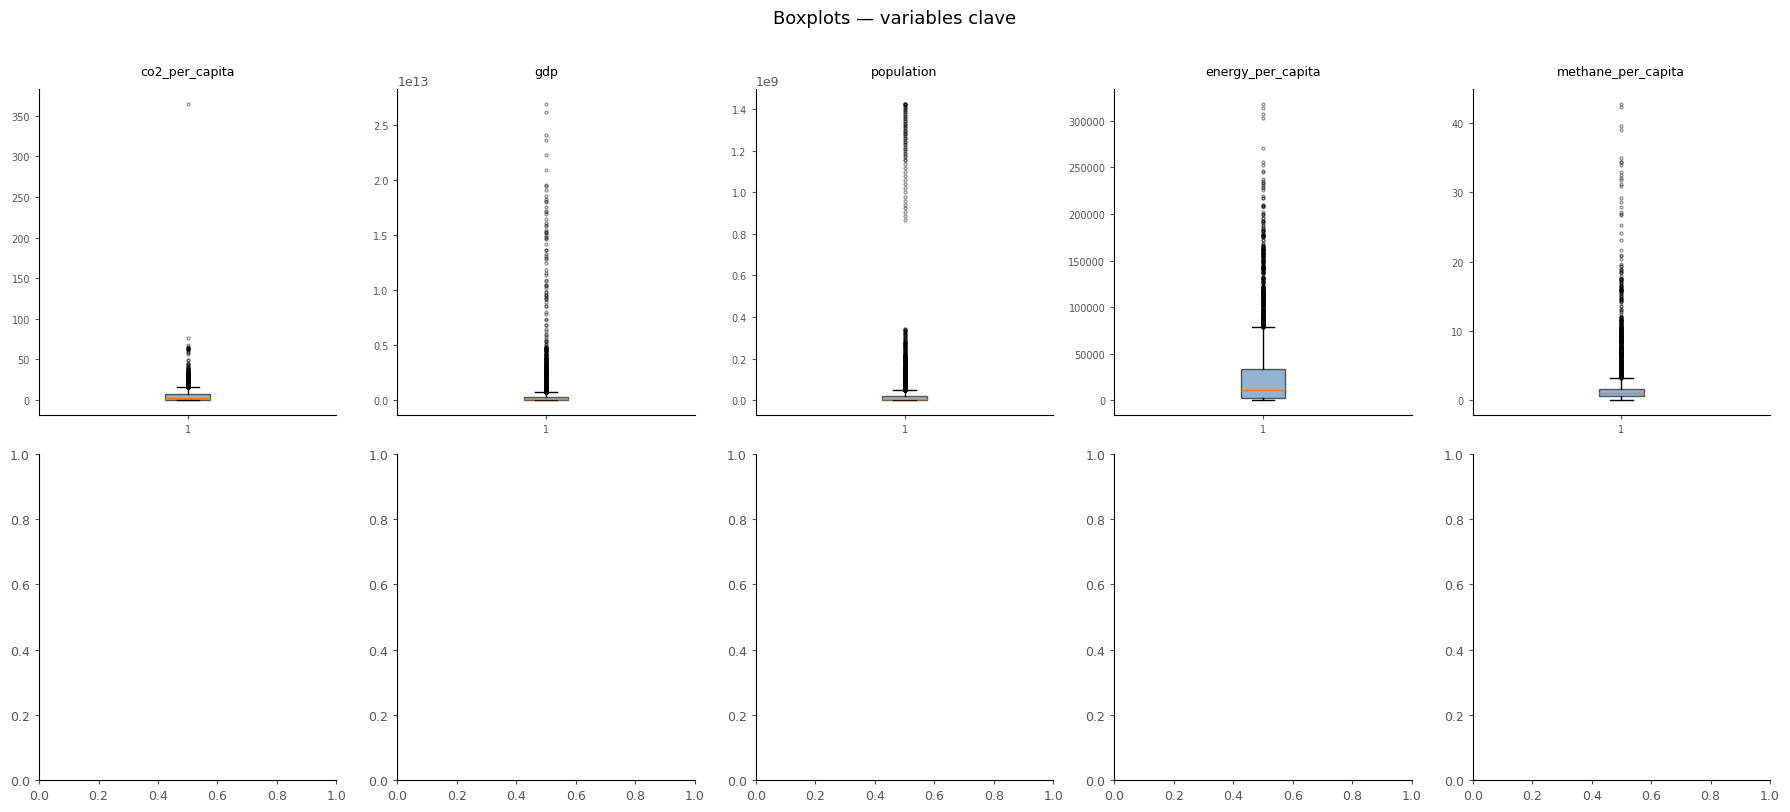

In [32]:
# === BOXPLOTS DE VARIABLES CLAVE ===
# Nos enfocamos en las variables más relevantes para el modelo
cols_key = [
    'co2_per_capita', 'co2', 'gdp', 'population',
    'energy_per_capita', 'oil_co2_per_capita',
    'methane_per_capita', 'ghg_per_capita',
    'land_use_change_co2', 'cement_co2_per_capita'
]
cols_key = [c for c in cols_key if c in df_clean.columns]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cols_key):
    data = df_clean[col].dropna()
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4, color='coral'))
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Boxplots — variables clave', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 4.4 Análisis de variables económicas: GDP y población

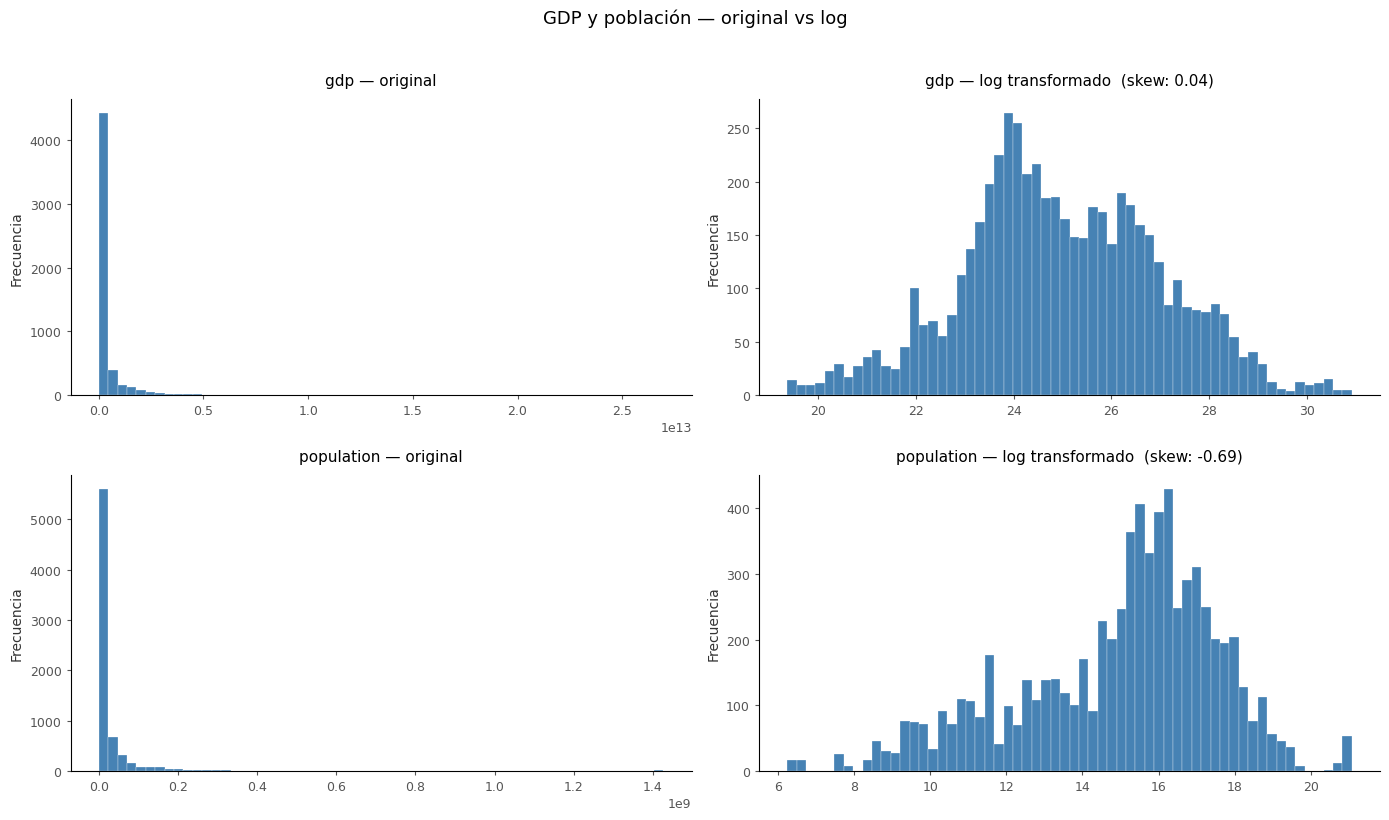

In [33]:

# === GDP Y POBLACIÓN ===
# Ambas variables tienen distribuciones muy asimétricas
# Analizamos original vs log para confirmar si conviene transformar

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(['gdp', 'population']):
    data = df_clean[col].dropna()

    # Original
    axes[i][0].hist(data, bins=60, color='steelblue', edgecolor='white', linewidth=0.2)
    axes[i][0].set_title(f'{col} — original', fontsize=11)
    axes[i][0].set_ylabel('Frecuencia')

    # Log
    log_data = np.log1p(data)
    axes[i][1].hist(log_data, bins=60, color='steelblue', edgecolor='white', linewidth=0.2)
    axes[i][1].set_title(f'{col} — log transformado  (skew: {log_data.skew():.2f})', fontsize=11)
    axes[i][1].set_ylabel('Frecuencia')

plt.suptitle('GDP y población — original vs log', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4.5 Fuentes de emisión por tipo

## 5. Análisis bivariado y correlaciones
En esta sección analizamos las relaciones entre los features y la variable respuesta `co2_per_capita`.

### 5.1 Matriz de correlaciones

La matriz de correlaciones de Pearson permite identificar el grado de asociación lineal
entre todas las variables numéricas del dataset. Se utiliza una paleta divergente
(**rojo** = correlación positiva, **azul** = correlación negativa) centrada en cero.

> La correlación de Pearson mide exclusivamente relaciones **lineales**.
> Variables con relaciones no lineales (como GDP y emisiones) pueden mostrar
> correlaciones bajas aún cuando la asociación real sea fuerte.

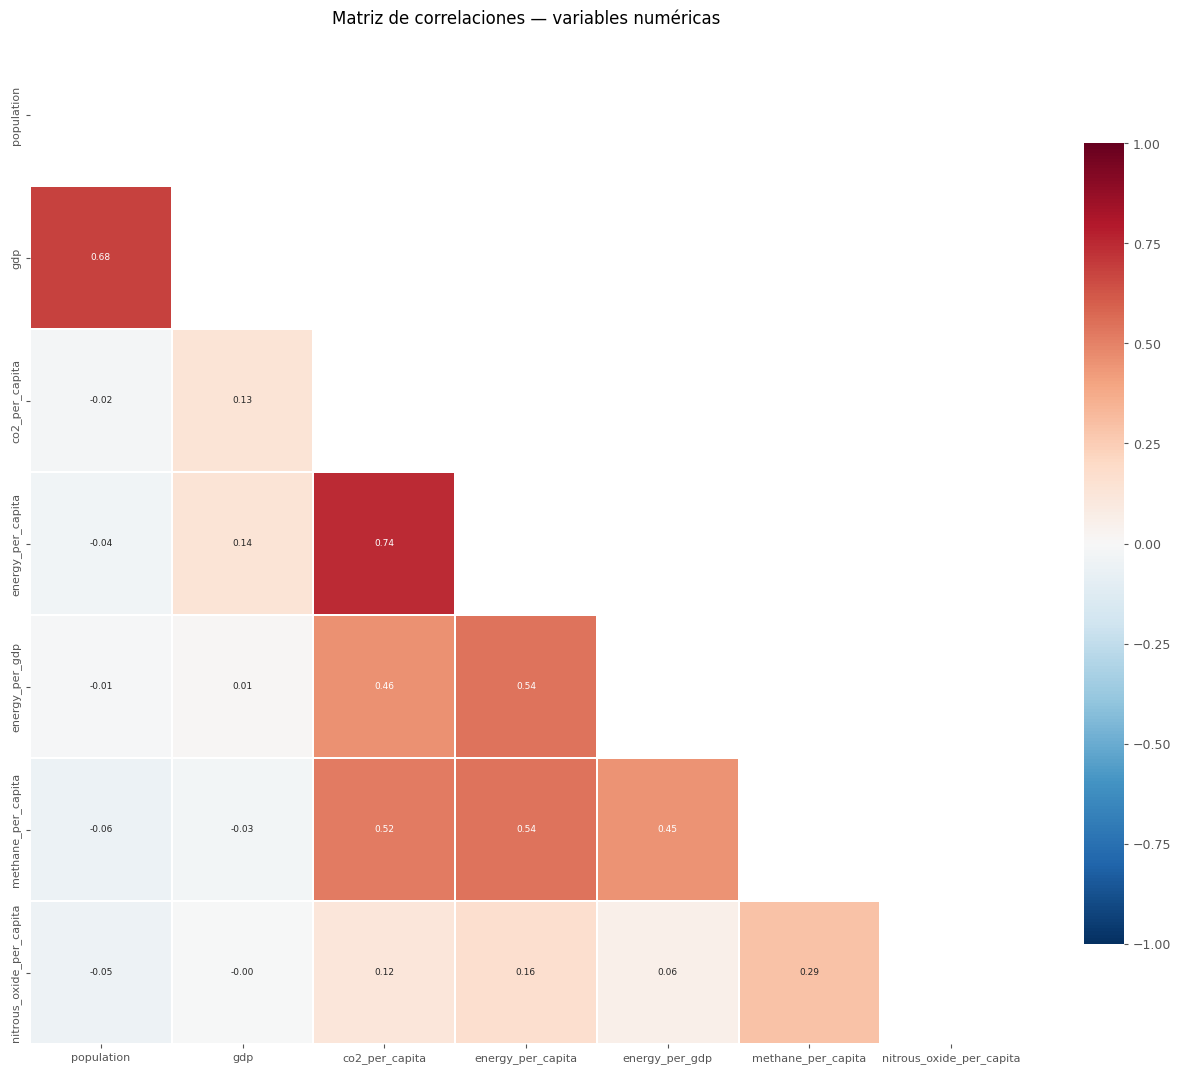

In [34]:
# === MATRIZ DE CORRELACIONES ===
numericas = df_clean.select_dtypes(include='number').drop(columns=['year'])
corr_matrix = numericas.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 6.5},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor='white',
    ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de correlaciones — variables numéricas', pad=14, fontsize=12)
ax.tick_params(labelsize=8)
plt.show()

Los principales hallazgos en esta matriz de correlación son:

| Variable | Correlación | Interpretación |
|---|---|---|
| `energy_per_capita` | 0.74 | Predictor más fuerte — el consumo energético explica gran parte de las emisiones |
| `methane_per_capita` | 0.52 | Asociado a ganadería e industria del gas |
| `energy_per_gdp` | 0.46 | Países con economías ineficientes energéticamente emiten más |
| `nitrous_oxide_per_capita` | 0.12 | Correlación baja — el óxido nitroso proviene principalmente del sector agrícola, que no necesariamente correlaciona con emisiones de CO₂ |
| `gdp` | 0.13 | Baja correlación — el GDP *total* no predice bien; importa el GDP *per cápita* |
| `population` | -0.02 | Sin correlación — el tamaño poblacional no determina emisiones per cápita |

> 💡 La baja correlación lineal de `gdp` con `co2_per_capita` no implica que no sean
> variables relacionadas — en escala log-log la correlación sube significativamente,
> como veremos en la sección 5.4.

### 5.3 Scatter plots — features vs co2_per_capita

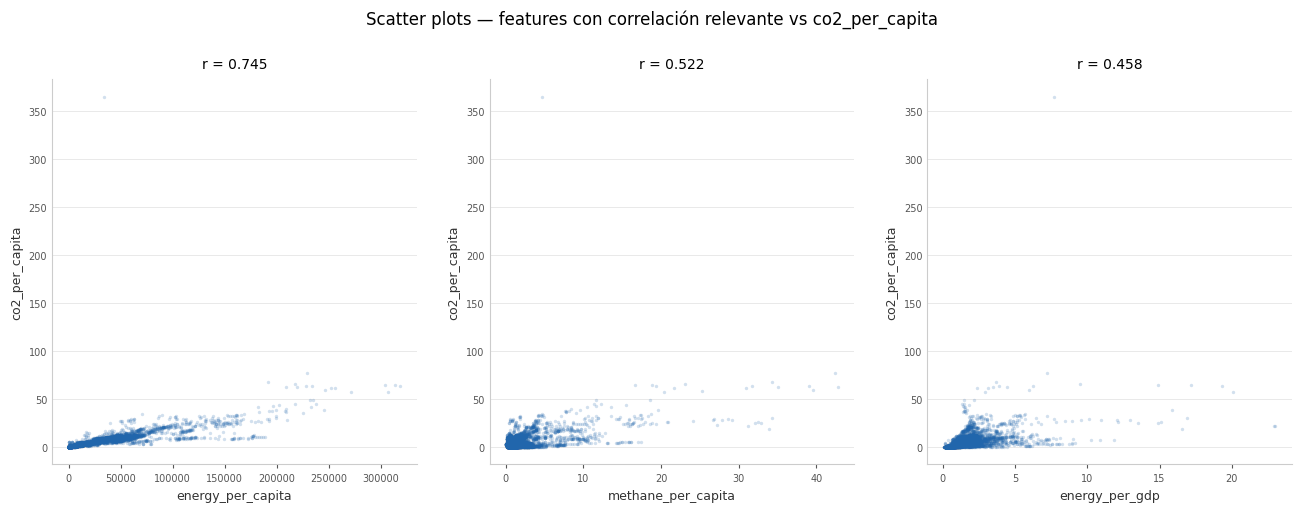

In [35]:
# === SCATTER PLOTS — FEATURES CON CORRELACIÓN RELEVANTE (versión completa) ===
features_relevantes = ['energy_per_capita', 'methane_per_capita', 'energy_per_gdp']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(features_relevantes):
    ax   = axes[i]
    data = df_clean[['co2_per_capita', col]].dropna()
    r    = data.corr().iloc[0, 1]

    ax.scatter(data[col], data['co2_per_capita'],
               alpha=0.2, s=6, color=C_BLUE, linewidths=0)
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('co2_per_capita', fontsize=9)
    ax.set_title(f'r = {r:.3f}', fontsize=10, pad=8)
    ax.tick_params(labelsize=7)
    tufte_style(ax, grid_axis='y')

fig.suptitle('Scatter plots — features con correlación relevante vs co2_per_capita',
             fontsize=12, y=1.02)
plt.show()

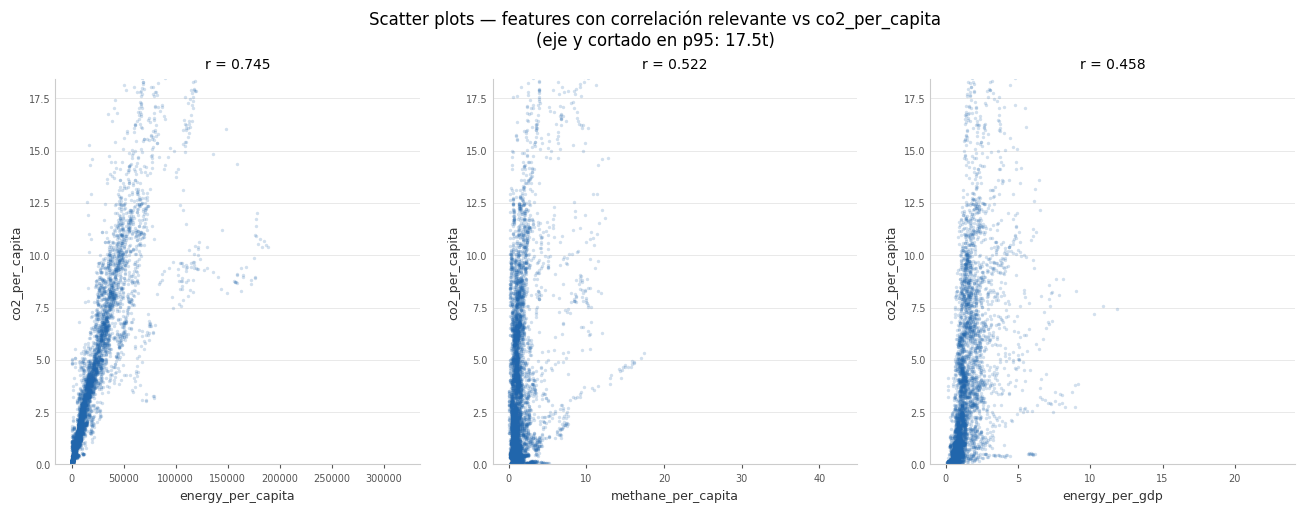

In [36]:
# === SCATTER PLOTS — FEATURES CON CORRELACIÓN RELEVANTE ===
features_relevantes = ['energy_per_capita', 'methane_per_capita', 'energy_per_gdp']

y_cap = df_clean['co2_per_capita'].quantile(0.95)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(features_relevantes):
    ax   = axes[i]
    data = df_clean[['co2_per_capita', col]].dropna()
    r    = data.corr().iloc[0, 1]

    ax.scatter(data[col], data['co2_per_capita'],
               alpha=0.2, s=6, color=C_BLUE, linewidths=0)
    ax.set_ylim(0, y_cap * 1.05)
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('co2_per_capita', fontsize=9)
    ax.set_title(f'r = {r:.3f}', fontsize=10, pad=8)
    ax.tick_params(labelsize=7)
    tufte_style(ax, grid_axis='y')

fig.suptitle(f'Scatter plots — features con correlación relevante vs co2_per_capita\n'
             f'(eje y cortado en p95: {y_cap:.1f}t)',
             fontsize=12, y=1.02)
plt.show()

Los scatter plots permiten visualizar la relación individual entre cada feature y la variable
respuesta, detectando patrones que la correlación de Pearson por sí sola no captura.

Se muestran únicamente los 3 features con correlación relevante (r > 0.4).
Las variables `gdp` (r = 0.134), `nitrous_oxide_per_capita` (r = 0.123) y
`population` (r = -0.022) mostraron correlación lineal prácticamente nula
y no se incluyen en los scatter plots.

**Hallazgos por variable:**

- **`energy_per_capita`** *(r = 0.745)* — relación más clara del dataset. A mayor
consumo energético per cápita, mayores emisiones de CO₂. La dispersión indica
que no es el único factor determinante.

- **`methane_per_capita`** *(r = 0.522)* — tendencia creciente pero con mayor ruido.
El metano proviene de sectores (ganadería, industria del gas) que no siempre
correlacionan directamente con las emisiones de CO₂.

- **`energy_per_gdp`** *(r = 0.458)* — los puntos se concentran en valores bajos
con algunos outliers hacia la derecha. La tendencia existe pero es menos pronunciada.

> 💡 **Conclusión general:** las relaciones son no lineales y con alta dispersión.
> Esto sugiere que una transformación logarítmica mejorará el ajuste, y que modelos
> no lineales como **Random Forest** o **Gradient Boosting** podrían capturar mejor
> estas relaciones que una regresión lineal simple — decisión a evaluar en el TP3.

### 5.4 GDP per cápita vs co2_per_capita — escala original y log-log

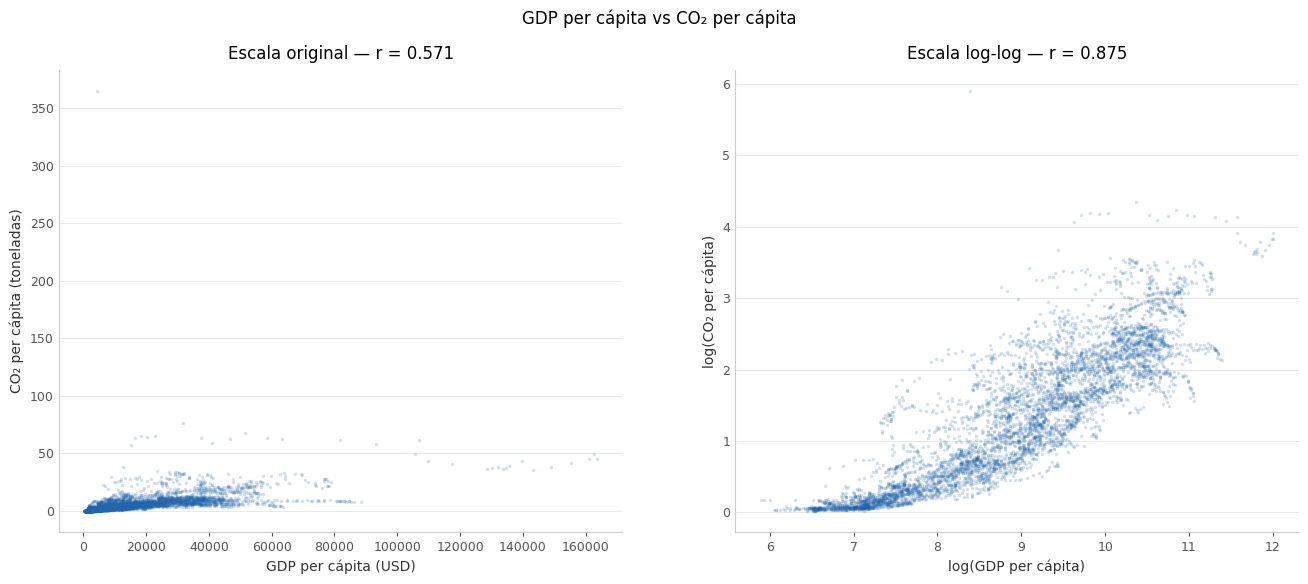

Correlación escala original: 0.571
Correlación escala log-log:  0.875


In [37]:
# === GDP PER CÁPITA VS CO2 PER CÁPITA ===
df_clean['gdp_per_capita'] = df_clean['gdp'] / df_clean['population']
data = df_clean[['country', 'year', 'gdp_per_capita', 'co2_per_capita']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

r_orig = data[['gdp_per_capita', 'co2_per_capita']].corr().iloc[0, 1]
axes[0].scatter(data['gdp_per_capita'], data['co2_per_capita'],
                alpha=0.2, s=6, color=C_BLUE, linewidths=0)
axes[0].set_xlabel('GDP per cápita (USD)')
axes[0].set_ylabel('CO₂ per cápita (toneladas)')
axes[0].set_title(f'Escala original — r = {r_orig:.3f}', pad=8)
tufte_style(axes[0], grid_axis='y')

log_gdp = np.log1p(data['gdp_per_capita'])
log_co2 = np.log1p(data['co2_per_capita'])
r_log   = np.corrcoef(log_gdp, log_co2)[0, 1]
axes[1].scatter(log_gdp, log_co2,
                alpha=0.2, s=6, color=C_BLUE, linewidths=0)
axes[1].set_xlabel('log(GDP per cápita)')
axes[1].set_ylabel('log(CO₂ per cápita)')
axes[1].set_title(f'Escala log-log — r = {r_log:.3f}', pad=8)
tufte_style(axes[1], grid_axis='y')

fig.suptitle('GDP per cápita vs CO₂ per cápita', fontsize=12)
plt.show()

print(f"Correlación escala original: {r_orig:.3f}")
print(f"Correlación escala log-log:  {r_log:.3f}")

### 5.5 Curva de Kuznets ambiental

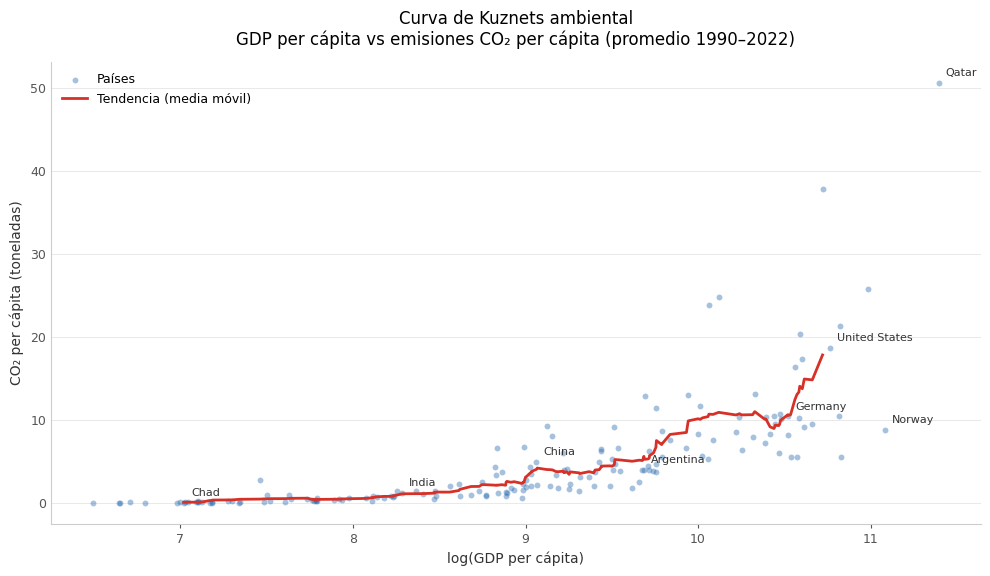

In [38]:
# === CURVA DE KUZNETS AMBIENTAL ===
kuznets = (df_clean.groupby('country')[['gdp_per_capita', 'co2_per_capita']]
           .mean().dropna().reset_index())
kuznets = kuznets.sort_values('gdp_per_capita')
kuznets['co2_smooth'] = (kuznets['co2_per_capita']
                         .rolling(window=15, center=True).mean())

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(np.log1p(kuznets['gdp_per_capita']),
           kuznets['co2_per_capita'],
           alpha=0.4, s=18, color=C_BLUE, linewidths=0, label='Países')
ax.plot(np.log1p(kuznets['gdp_per_capita']),
        kuznets['co2_smooth'],
        color=C_RED, linewidth=2, label='Tendencia (media móvil)')

destacados = ['Qatar', 'United States', 'China', 'India',
              'Germany', 'Argentina', 'Chad', 'Norway']
for _, row in kuznets[kuznets['country'].isin(destacados)].iterrows():
    ax.annotate(row['country'],
                xy=(np.log1p(row['gdp_per_capita']), row['co2_per_capita']),
                fontsize=8, color='#333333',
                xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('log(GDP per cápita)')
ax.set_ylabel('CO₂ per cápita (toneladas)')
ax.set_title('Curva de Kuznets ambiental\n'
             'GDP per cápita vs emisiones CO₂ per cápita (promedio 1990–2022)',
             pad=12)
ax.legend(frameon=False)
tufte_style(ax, grid_axis='y')
plt.show()

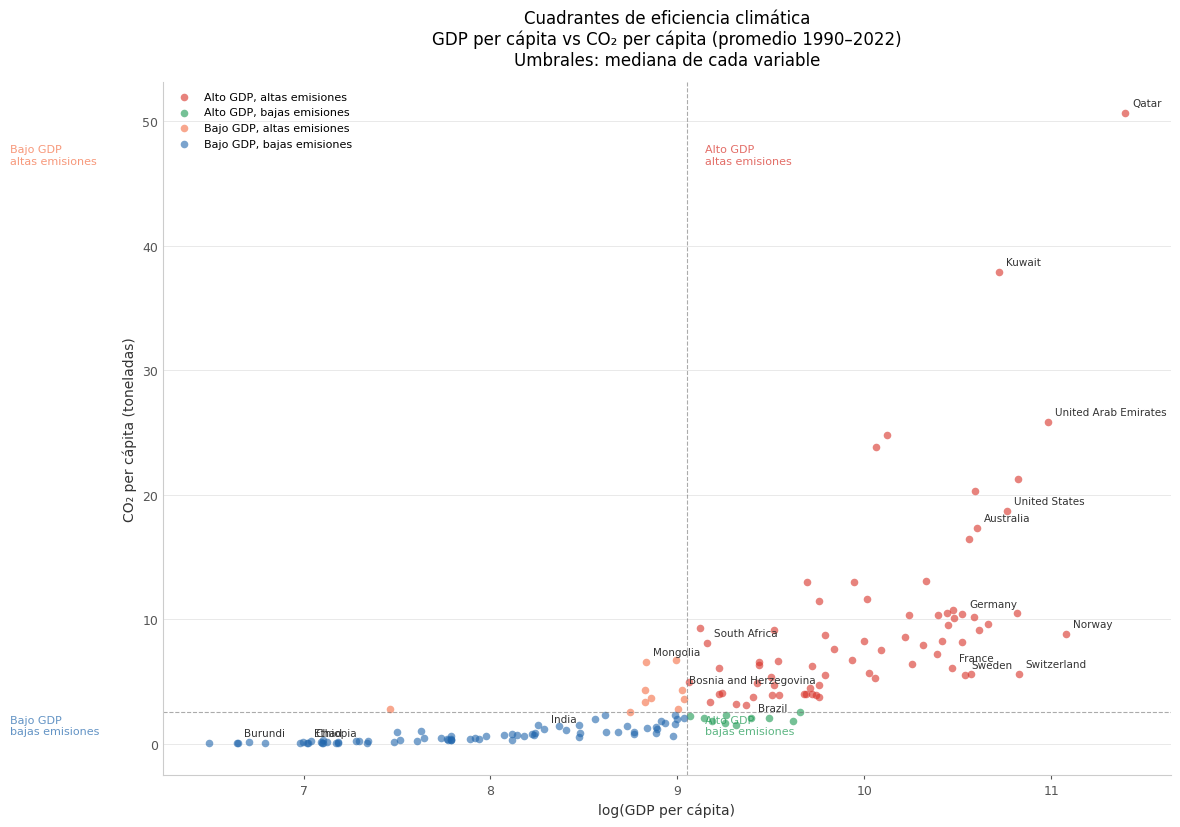

Países por cuadrante:

Alto GDP, altas emisiones (72 países):
Algeria, Argentina, Australia, Austria, Azerbaijan, Bahrain, Barbados, Belarus, Belgium, Bulgaria ...

Alto GDP, bajas emisiones (10 países):
Botswana, Brazil, Colombia, Costa Rica, Dominican Republic, Georgia, Mauritius, Panama, Tunisia, Uruguay 

Bajo GDP, altas emisiones (10 países):
Bosnia and Herzegovina, Iraq, Jamaica, Jordan, Lebanon, Mongolia, North Korea, Syria, Ukraine, Uzbekistan 

Bajo GDP, bajas emisiones (72 países):
Afghanistan, Albania, Angola, Armenia, Bangladesh, Benin, Bolivia, Burkina Faso, Burundi, Cambodia ...


In [39]:
# === GRÁFICO DE 4 CUADRANTES — GDP per cápita vs CO₂ per cápita ===
df_quad = df_clean.groupby('country')[['gdp_per_capita', 'co2_per_capita']].mean().dropna()

# Umbrales — mediana de cada variable
gdp_med = df_quad['gdp_per_capita'].median()
co2_med = df_quad['co2_per_capita'].median()

# Asignar cuadrante
def asignar_cuadrante(row):
    if row['gdp_per_capita'] >= gdp_med and row['co2_per_capita'] >= co2_med:
        return 'Alto GDP, altas emisiones'
    elif row['gdp_per_capita'] >= gdp_med and row['co2_per_capita'] < co2_med:
        return 'Alto GDP, bajas emisiones'
    elif row['gdp_per_capita'] < gdp_med and row['co2_per_capita'] >= co2_med:
        return 'Bajo GDP, altas emisiones'
    else:
        return 'Bajo GDP, bajas emisiones'

df_quad['cuadrante'] = df_quad.apply(asignar_cuadrante, axis=1)

# Colores por cuadrante — ColorBrewer
colores_quad = {
    'Alto GDP, altas emisiones':  C_RED,
    'Alto GDP, bajas emisiones':  C_GREEN,
    'Bajo GDP, altas emisiones':  C_ORANGE,
    'Bajo GDP, bajas emisiones':  C_BLUE,
}

# Países a etiquetar por cuadrante
etiquetas = {
    'Alto GDP, altas emisiones':  ['Qatar', 'Kuwait', 'United Arab Emirates',
                                   'United States', 'Australia'],
    'Alto GDP, bajas emisiones':  ['Norway', 'Switzerland', 'France',
                                   'Sweden', 'Germany'],
    'Bajo GDP, altas emisiones':  ['South Africa', 'Mongolia',
                                   'Bosnia and Herzegovina'],
    'Bajo GDP, bajas emisiones':  ['Chad', 'Burundi', 'Ethiopia',
                                   'India', 'Brazil'],
}

fig, ax = plt.subplots(figsize=(13, 9))

for cuad, color in colores_quad.items():
    subset = df_quad[df_quad['cuadrante'] == cuad]
    ax.scatter(np.log1p(subset['gdp_per_capita']),
               subset['co2_per_capita'],
               color=color, alpha=0.6, s=30,
               linewidths=0, label=cuad)

# Etiquetar países destacados
for cuad, paises in etiquetas.items():
    for pais in paises:
        if pais in df_quad.index:
            row = df_quad.loc[pais]
            ax.annotate(pais,
                        xy=(np.log1p(row['gdp_per_capita']), row['co2_per_capita']),
                        fontsize=7.5, color='#333333',
                        xytext=(5, 5), textcoords='offset points')

# Líneas de los umbrales
ax.axvline(np.log1p(gdp_med), color=C_GRAY, linewidth=0.8,
           linestyle='--', alpha=0.6)
ax.axhline(co2_med, color=C_GRAY, linewidth=0.8,
           linestyle='--', alpha=0.6)

# Etiquetas de cuadrantes
ax.text(np.log1p(gdp_med) + 0.1, df_quad['co2_per_capita'].max() * 0.92,
        'Alto GDP\naltas emisiones', fontsize=8, color=C_RED, alpha=0.7)
ax.text(np.log1p(gdp_med) + 0.1, co2_med * 0.3,
        'Alto GDP\nbajas emisiones', fontsize=8, color=C_GREEN, alpha=0.7)
ax.text(np.log1p(gdp_med) * 0.6, df_quad['co2_per_capita'].max() * 0.92,
        'Bajo GDP\naltas emisiones', fontsize=8, color=C_ORANGE, alpha=0.7)
ax.text(np.log1p(gdp_med) * 0.6, co2_med * 0.3,
        'Bajo GDP\nbajas emisiones', fontsize=8, color=C_BLUE, alpha=0.7)

ax.set_xlabel('log(GDP per cápita)')
ax.set_ylabel('CO₂ per cápita (toneladas)')
ax.set_title('Cuadrantes de eficiencia climática\n'
             'GDP per cápita vs CO₂ per cápita (promedio 1990–2022)\n'
             'Umbrales: mediana de cada variable',
             pad=12)
ax.legend(frameon=False, fontsize=8, loc='upper left')
tufte_style(ax, grid_axis='y')
plt.show()

# Resumen por cuadrante
print("Países por cuadrante:")
for cuad in colores_quad.keys():
    paises = df_quad[df_quad['cuadrante'] == cuad].index.tolist()
    print(f"\n{cuad} ({len(paises)} países):")
    print(', '.join(paises[:10]), '...' if len(paises) > 10 else '')